**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión** · Complemento de la clase 14

---

# 🏛️ ROE, ROA y EBITDA desde los balances oficiales (SEC)

En la clase 14 calculamos ROE, ROA y margen EBITDA de Microsoft, Coca-Cola y Apple con `yfinance`.
Yahoo **no inventa** esos números: los saca de los balances que cada empresa presenta ante la
**SEC** (*Securities and Exchange Commission*, el regulador bursátil de EE.UU.) y los reprocesa.

Acá vamos **a la fuente**: leemos los balances oficiales directamente, sin intermediarios.

| | `yfinance` (clase 14) | SEC (este complemento) |
|---|---|---|
| Qué es | Datos reprocesados por Yahoo | El balance oficial, tal cual lo presentó la empresa |
| Líneas de código | ~8 | ~50 |
| Definiciones | Las de Yahoo (ej.: su propio EBITDA) | Las contables, y sabés de qué partida sale cada número |
| Para qué sirve | Un pantallazo rápido | Auditar un número, o cuando Yahoo no coincide |

> ⚠️ **Esto es profundización: no entra en el parcial.** Es para quien quiera ver cómo se trabaja
> con la fuente primaria, que es lo que se hace en un área de análisis financiero en serio.

## 1. ¿Qué es lo que vamos a leer?

Toda empresa que cotiza en EE.UU. presenta cada año un formulario llamado **10-K**: es su memoria y
balance anual, auditado. Desde hace unos años, además del PDF, la SEC exige que los números vengan
en un formato que una computadora puede leer, llamado **XBRL**: cada número viene con una
**etiqueta** que dice qué es (por ejemplo `NetIncomeLoss` = resultado neto).

La SEC publica todo eso gratis en una **API**: una dirección web que, en vez de devolver una página,
devuelve datos. Para pedir los de una empresa se necesita su **CIK**, el número que la SEC le asigna
a cada empresa (como un CUIT).

| Empresa | Ticker | CIK |
|---|---|---|
| Microsoft | MSFT | 0000789019 |
| Coca-Cola | KO | 0000021344 |
| Apple | AAPL | 0000320193 |

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# La SEC pide que cada consulta diga quién la hace (el "User-Agent").
# Si no lo ponemos, puede rechazar el pedido.
ENCABEZADO = {"User-Agent": "Laboratorio Metodos Cuantitativos FCE-UBA uso educativo"}

EMPRESAS = {"MSFT": "0000789019", "KO": "0000021344", "AAPL": "0000320193"}

## 2. Pedir los datos de Microsoft

La dirección es siempre la misma; solo cambia el CIK al final.

In [2]:
url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{EMPRESAS['MSFT']}.json"
respuesta = requests.get(url, headers=ENCABEZADO)

print("Código de respuesta:", respuesta.status_code)   # 200 = todo bien

datos = respuesta.json()   # el contenido viene en formato JSON: diccionarios dentro de diccionarios
print("Empresa:", datos["entityName"])

Código de respuesta: 200
Empresa: MICROSOFT CORPORATION


## 3. ¿Cómo viene organizado?

El JSON es una **caja dentro de otra caja**. Lo que nos importa está en `datos["facts"]["us-gaap"]`:
`us-gaap` son las normas contables de EE.UU., y adentro hay **una entrada por cada etiqueta
contable**. Veamos cuántas hay y algunas de ejemplo:

In [3]:
etiquetas = datos["facts"]["us-gaap"]
print("Cantidad de etiquetas contables:", len(etiquetas))
print()
for nombre in ["NetIncomeLoss", "OperatingIncomeLoss", "Assets", "StockholdersEquity"]:
    print(f"{nombre:22s} ->", etiquetas[nombre]["label"])

Cantidad de etiquetas contables: 562

NetIncomeLoss          -> Net Income (Loss) Attributable to Parent
OperatingIncomeLoss    -> Operating Income (Loss)
Assets                 -> Assets
StockholdersEquity     -> Stockholders' Equity Attributable to Parent


Cada etiqueta tiene **todos los valores que la empresa reportó alguna vez** con ese nombre. Miremos
los primeros del resultado neto:

In [4]:
valores_neto = pd.DataFrame(etiquetas["NetIncomeLoss"]["units"]["USD"])
valores_neto[["start", "end", "val", "fy", "fp", "form"]].tail(8)

,start,end,val,fy,fp,form
332,2024-07-01,2025-06-30,101832000000,2025.0,FY,10-K
333,2024-07-01,2025-06-30,101832000000,2026.0,FY,10-K
334,2025-07-01,2025-09-30,27747000000,2026.0,Q1,10-Q
335,2025-07-01,2025-12-31,66205000000,2026.0,Q2,10-Q
336,2025-10-01,2025-12-31,38458000000,2026.0,Q2,10-Q
337,2025-07-01,2026-03-31,97983000000,2026.0,Q3,10-Q
338,2026-01-01,2026-03-31,31778000000,2026.0,Q3,10-Q
339,2025-07-01,2026-06-30,133749000000,2026.0,FY,10-K


**Qué es cada columna:**

| Columna | Qué significa |
|---|---|
| `start`, `end` | Desde y hasta cuándo es el dato |
| `val` | El valor, en dólares |
| `form` | En qué formulario vino: `10-K` (anual) o `10-Q` (trimestral) |
| `fp` | Período fiscal: `FY` = año completo; `Q1`, `Q2`, `Q3` = trimestres |
| `fy` | ⚠️ El año **del formulario**, no del dato |

Fijate que el mismo número aparece **repetido**: cada 10-K trae el año actual **y los dos
anteriores** para comparar. Por eso hay que filtrar con cuidado.

## 4. Filtrar: quedarnos con un valor por año

Tres reglas, cada una con su porqué:

1. **Solo el formulario anual** (`form == "10-K"` y `fp == "FY"`): no queremos trimestres.
2. **Si es un flujo** (algo que pasa *durante* un período, como el resultado neto), que el período
   dure **un año** (entre 350 y 380 días). Los saldos del balance (activo, patrimonio) son una foto
   en una fecha y no tienen `start`.
3. **El año sale de `end`** (la fecha de cierre), **no de `fy`**: un 10-K de 2026 trae datos de
   2024, 2025 y 2026, todos con `fy = 2026`. Si agrupáramos por `fy`, mezclaríamos años.

In [5]:
def valores_anuales(etiquetas, nombre):
    # Devuelve {año de cierre: valor} con un valor por año, siguiendo las tres reglas
    if nombre not in etiquetas:
        return {}
    resultado = {}
    for dato in etiquetas[nombre]["units"].get("USD", []):
        # Regla 1: solo el formulario anual, año completo
        if dato.get("form") != "10-K" or dato.get("fp") != "FY":
            continue
        # Regla 2: si es un flujo, que dure un año
        if "start" in dato:
            dias = (date.fromisoformat(dato["end"]) - date.fromisoformat(dato["start"])).days
            if not 350 <= dias <= 380:
                continue
        # Regla 3: el año sale del cierre
        resultado[int(dato["end"][:4])] = dato["val"]
    return resultado

neto_msft = valores_anuales(etiquetas, "NetIncomeLoss")
{año: f"{valor / 1e6:,.0f} M" for año, valor in sorted(neto_msft.items())[-5:]}

{2022: '72,738 M',
 2023: '72,361 M',
 2024: '88,136 M',
 2025: '101,832 M',
 2026: '133,749 M'}

## 5. La trampa de las etiquetas: cada empresa reporta distinto

Las normas permiten nombrar algunas partidas de más de una forma. Por ejemplo, los **ingresos**
pueden venir como `Revenues` o como `RevenueFromContractWithCustomerExcludingAssessedTax`, según la
empresa. Y **Microsoft no reporta las amortizaciones en una sola partida**: las separa en
depreciación y amortización de intangibles.

Por eso, para cada concepto armamos una **lista de etiquetas posibles** y usamos la primera que
aparezca:

In [6]:
ETIQUETAS_POSIBLES = {
    "ingresos":       ["RevenueFromContractWithCustomerExcludingAssessedTax", "Revenues"],
    "operativo":      ["OperatingIncomeLoss"],
    "neto":           ["NetIncomeLoss"],
    "amortizaciones": ["DepreciationDepletionAndAmortization", "DepreciationAndAmortization"],
    "activo":         ["Assets"],
    "patrimonio":     ["StockholdersEquity"],
}

def primera_que_exista(etiquetas, posibles):
    for nombre in posibles:
        serie = valores_anuales(etiquetas, nombre)
        if serie:
            return serie, nombre
    return {}, None

for concepto, posibles in ETIQUETAS_POSIBLES.items():
    serie, nombre = primera_que_exista(etiquetas, posibles)
    print(f"{concepto:15s} -> {nombre}")

ingresos        -> RevenueFromContractWithCustomerExcludingAssessedTax
operativo       -> OperatingIncomeLoss
neto            -> NetIncomeLoss
amortizaciones  -> None
activo          -> Assets
patrimonio      -> StockholdersEquity


Las amortizaciones de Microsoft salieron `None`: no usa ninguna de esas dos etiquetas. Las armamos
sumando sus dos partidas:

In [7]:
depreciacion = valores_anuales(etiquetas, "Depreciation")
intangibles  = valores_anuales(etiquetas, "AmortizationOfIntangibleAssets")
amortizaciones_msft = {año: depreciacion[año] + intangibles[año]
                       for año in depreciacion if año in intangibles}
{año: f"{valor / 1e6:,.0f} M" for año, valor in sorted(amortizaciones_msft.items())[-3:]}

{2024: '20,000 M', 2025: '28,000 M', 2026: '39,000 M'}

> 🔍 **Fijate que son números redondos.** Microsoft carga estas dos partidas en las **notas** del
> balance, redondeadas a cientos de millones ("la depreciación fue de US\$ 34,3 mil millones"). En su
> estado de flujo de efectivo usa una partida **propia** ("depreciación, amortización y otros") que
> la API estándar no trae. Es una aproximación razonable, pero conviene saberlo: **no todo dato
> oficial es igual de preciso**.

## 6. Juntar todo en una función

Ahora sí: los pasos 2 a 5 en una sola función, que devuelve las cuentas del **último año
disponible** de cualquier empresa.

$$
EBITDA = \text{Resultado operativo} + \text{Amortizaciones}
\qquad
ROE = \frac{\text{Neto}}{\text{Patrimonio}}
\qquad
ROA = \frac{\text{Neto}}{\text{Activo}}
$$

In [8]:
def metricas_sec(ticker):
    # 1) Pedir los datos
    url = f"https://data.sec.gov/api/xbrl/companyfacts/CIK{EMPRESAS[ticker]}.json"
    etiquetas = requests.get(url, headers=ENCABEZADO).json()["facts"]["us-gaap"]

    # 2) Un valor por año para cada concepto
    series = {c: primera_que_exista(etiquetas, p)[0] for c, p in ETIQUETAS_POSIBLES.items()}
    if not series["amortizaciones"]:   # caso Microsoft: dos partidas separadas
        dep = valores_anuales(etiquetas, "Depreciation")
        intang = valores_anuales(etiquetas, "AmortizationOfIntangibleAssets")
        series["amortizaciones"] = {a: dep[a] + intang[a] for a in dep if a in intang}

    # 3) El último año que tenga TODOS los conceptos
    año = max(set.intersection(*(set(s) for s in series.values())))
    v = {c: s[año] for c, s in series.items()}

    # 4) Las cuentas
    ebitda = v["operativo"] + v["amortizaciones"]
    return {
        "Empresa":        ticker,
        "Ejercicio":      año,
        "ROE":            v["neto"] / v["patrimonio"],
        "ROA":            v["neto"] / v["activo"],
        "Margen EBITDA":  ebitda / v["ingresos"],
        "Apalancamiento": v["activo"] / v["patrimonio"],
    }

sec = pd.DataFrame([metricas_sec(t) for t in EMPRESAS])
sec.style.format({"ROE": "{:.1%}", "ROA": "{:.1%}", "Margen EBITDA": "{:.1%}", "Apalancamiento": "{:.2f}x"})

,Empresa,Ejercicio,ROE,ROA,Margen EBITDA,Apalancamiento
0,MSFT,2026,30.2%,17.6%,58.5%,1.71x
1,KO,2025,40.7%,12.5%,30.9%,3.26x
2,AAPL,2025,151.9%,31.2%,34.8%,4.87x


## 7. ¿Coincide con Yahoo?

Hacemos lo mismo con `yfinance` (las mismas 8 líneas de la clase) y comparamos.

In [9]:
import yfinance as yf

def metricas_yahoo(ticker):
    empresa = yf.Ticker(ticker)
    r, b = empresa.financials, empresa.balance_sheet
    neto, patrimonio, activo = r.loc["Net Income"].iloc[0], b.loc["Stockholders Equity"].iloc[0], b.loc["Total Assets"].iloc[0]
    return {"Empresa": ticker, "ROE": neto / patrimonio, "ROA": neto / activo,
            "Margen EBITDA": r.loc["EBITDA"].iloc[0] / r.loc["Total Revenue"].iloc[0]}

yahoo = pd.DataFrame([metricas_yahoo(t) for t in EMPRESAS])

comparacion = sec[["Empresa", "ROE", "ROA", "Margen EBITDA"]].merge(yahoo, on="Empresa", suffixes=(" SEC", " Yahoo"))
comparacion = comparacion[["Empresa", "ROE SEC", "ROE Yahoo", "ROA SEC", "ROA Yahoo", "Margen EBITDA SEC", "Margen EBITDA Yahoo"]]
comparacion.style.format({c: "{:.1%}" for c in comparacion.columns if c != "Empresa"})

,Empresa,ROE SEC,ROE Yahoo,ROA SEC,ROA Yahoo,Margen EBITDA SEC,Margen EBITDA Yahoo
0,MSFT,30.2%,30.2%,17.6%,17.6%,58.5%,62.5%
1,KO,40.7%,40.7%,12.5%,12.5%,30.9%,39.0%
2,AAPL,151.9%,151.9%,31.2%,31.2%,34.8%,34.8%


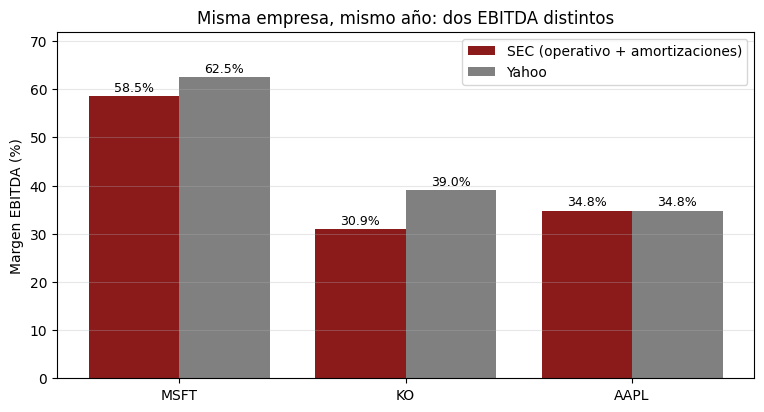

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comparacion))
ax.bar(x - 0.2, comparacion["Margen EBITDA SEC"] * 100, width=0.4, color="#8B1A1A", label="SEC (operativo + amortizaciones)")
ax.bar(x + 0.2, comparacion["Margen EBITDA Yahoo"] * 100, width=0.4, color="gray", label="Yahoo")
for i, fila in comparacion.iterrows():
    ax.text(i - 0.2, fila["Margen EBITDA SEC"] * 100 + 1, f"{fila['Margen EBITDA SEC']:.1%}", ha="center", fontsize=9)
    ax.text(i + 0.2, fila["Margen EBITDA Yahoo"] * 100 + 1, f"{fila['Margen EBITDA Yahoo']:.1%}", ha="center", fontsize=9)
ax.set_xticks(x, comparacion["Empresa"])
ax.set_ylabel("Margen EBITDA (%)")
ax.set_ylim(0, max(comparacion["Margen EBITDA SEC"].max(), comparacion["Margen EBITDA Yahoo"].max()) * 100 * 1.15)
ax.set_title("Misma empresa, mismo año: dos EBITDA distintos")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.show()

## 🧠 ¿Qué aprendimos?

- **ROE y ROA coinciden** con Yahoo: el resultado neto, el activo y el patrimonio son partidas
  contables sin vueltas, y Yahoo las toma tal cual.
- **El EBITDA a veces coincide y a veces no.** En Apple da igual; en Microsoft y Coca-Cola, Yahoo da
  bastante más. El EBITDA **no es una partida contable obligatoria**: cada uno la arma a su manera.
  Nosotros usamos la definición estándar (operativo + amortizaciones); Yahoo suma más partidas
  (en Microsoft, probablemente la de "depreciación, amortización **y otros**" del flujo de efectivo).
- **Por eso conviene saber leer la fuente:** cuando dos sitios dan números distintos, el balance
  oficial es el árbitro.

> 🎯 **La moraleja, que vale para cualquier métrica:** antes de comparar un número, fijate **de
> dónde sale** y **cómo está calculado**.

---

### 📝 Para practicar

1. Agregá **Mercado Libre** (ticker `MELI`, CIK `0001099590`) al diccionario `EMPRESAS` y corré todo
   de nuevo. ¿Su ROE viene de un buen negocio o del apalancamiento?
2. Con `valores_anuales`, armá la serie de **ROE de Microsoft de los últimos 5 años**. ¿Sube o baja?
   ¿Qué pasó con el patrimonio en ese tiempo?
3. Buscá en `etiquetas` alguna partida que te interese (por ejemplo `ResearchAndDevelopmentExpense`,
   el gasto en investigación y desarrollo) y calculá qué porcentaje de los ingresos representa.